<a href="https://colab.research.google.com/github/hmnaz213/native/blob/main/Stanbic_SIMS_Parser.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Mount Google Drive

First, I'll mount your Google Drive to allow access to the file.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### Install PDF Parsing Library

Next, I'll install `PyPDF2` to extract text from the PDF file.

In [ ]:
!pip install PyPDF2

### Load and Parse the PDF

Now, I will load the PDF file and attempt to extract its text content. I will print the first few pages to understand its structure.

In [ ]:
import PyPDF2

pdf_path = '/content/drive/My Drive/2026/baobab/baobab_1/Stanbic SIMS 23052026.pdf'

def extract_text_from_pdf(pdf_path, num_pages=5):
    text_content = []
    try:
        with open(pdf_path, 'rb') as file:
            reader = PyPDF2.PdfReader(file)
            num_total_pages = len(reader.pages)
            print(f"Total pages in PDF: {num_total_pages}")
            for i in range(min(num_pages, num_total_pages)):
                page = reader.pages[i]
                text_content.append(page.extract_text())
    except FileNotFoundError:
        print(f"Error: The file '{pdf_path}' was not found.")
        return None
    except Exception as e:
        print(f"An error occurred: {e}")
        return None
    return text_content

extracted_pages_text = extract_text_from_pdf(pdf_path)

if extracted_pages_text:
    for i, page_text in enumerate(extracted_pages_text):
        print(f"\n--- Page {i+1} ---\n")
        print(page_text[:1000]) # Print first 1000 characters of each page for brevity
        if len(page_text) > 1000:
            print("... (truncated)")
else:
    print("Could not extract text from the PDF.")

### Parsing Investment Summary and Transaction Details

I will now parse the extracted text to pull out the structured information from the 'Investment Summary' on page 1 and the 'Transaction Details' on pages 3 and 4. I'll use regular expressions and string manipulation to achieve this.

In [ ]:
import re
import pandas as pd

def parse_investment_summary(text):
    summary_data = []

    # Pattern for STANBIC INCOME FUNDTRUST - AMC
    # This pattern accounts for the newline after "AMC" and the implicit 0 for "Total Withdrawal"
    pattern_amc = re.compile(r"STANBIC\sINCOME\sFUNDTRUST\s-\s\nAMC([\d.,]+)\s+([\d.,]+)\s+([\d.,]+)\s+([\d.,]+)\s+([\d.,]+)\s+([\d.,]+)\s+([\d.,]+)", re.DOTALL)
    match_amc = pattern_amc.search(text)
    if match_amc:
        summary_data.append({
            'Fund Name': 'STANBIC INCOME FUNDTRUST - AMC',
            'Total Contribution (GHS)': float(match_amc.group(1).replace(',', '')),
            'Total Withdrawal (GHS)': 0.0, # Assumed 0 as it's missing in the text for this fund
            'Units Outstanding': float(match_amc.group(2).replace(',', '')),
            'Amortized Price Per Unit (GHS)': float(match_amc.group(3).replace(',', '')),
            'Gains since inception (GHS)': float(match_amc.group(4).replace(',', '')),
            'MTM Price Per Unit (GHS)': float(match_amc.group(5).replace(',', '')),
            'Amortized Value (GHS)': float(match_amc.group(6).replace(',', '')),
            'MTM Value (GHS)': float(match_amc.group(7).replace(',', ''))
        })

    # Pattern for STANBIC Income Fund Trust (single line, all columns present)
    pattern_sift = re.compile(r"STANBIC\sIncome\sFund\sTrust\s+([\d.,]+)\s+([\d.,]+)\s+([\d.,]+)\s+([\d.,]+)\s+([\d.,]+)\s+([\d.,]+)\s+([\d.,]+)\s+([\d.,]+)")
    match_sift = pattern_sift.search(text)
    if match_sift:
        summary_data.append({
            'Fund Name': 'STANBIC Income Fund Trust',
            'Total Contribution (GHS)': float(match_sift.group(1).replace(',', '')),
            'Total Withdrawal (GHS)': float(match_sift.group(2).replace(',', '')),
            'Units Outstanding': float(match_sift.group(3).replace(',', '')),
            'Amortized Price Per Unit (GHS)': float(match_sift.group(4).replace(',', '')),
            'Gains since inception (GHS)': float(match_sift.group(5).replace(',', '')),
            'MTM Price Per Unit (GHS)': float(match_sift.group(6).replace(',', '')),
            'Amortized Value (GHS)': float(match_sift.group(7).replace(',', '')),
            'MTM Value (GHS)': float(match_sift.group(8).replace(',', ''))
        })

    return pd.DataFrame(summary_data)

def parse_transaction_details(text, fund_name_hint):
    transactions = []

    # Locate the start of the transaction block for the specific fund
    fund_start_match = re.search(f"Transaction Details for Period:.*?{re.escape(fund_name_hint)}", text, re.DOTALL)

    if not fund_start_match:
        return pd.DataFrame()

    fund_section_text = text[fund_start_match.end():]

    # We need to find where this section ends, typically before another 'Transaction Details' or 'Description Pledge Available Total'
    end_match = re.search(r"^(Description Pledge Available Total|STATEMENT OF INVESTMENTS)", fund_section_text, re.MULTILINE)
    if end_match:
        fund_section_text = fund_section_text[:end_match.start()]


    # Iterating over lines might be safer for transaction details given the variable spacing
    lines = fund_section_text.split('\n')
    for line in lines:
        line = line.strip()
        if line and not line.startswith('Value date') and not line.startswith('-----') and not line.startswith('Closing Balance') and not line.startswith('Description'):
            # This regex is still tricky. Let's try to parse based on expected column positions or more relaxed regex
            # Re-evaluating the regex for each line as it has a fixed structure within the table.
            # Value date Transaction Description Gross Amount Initial Fee Exit Fee Total Fee Net Amount Nav Price Units
            # 23-May-2025      Opening_Balance 43.86 (This is Units)
            # 29-Sep-2025 MF-BUY 200.00 0.00 0.00 0.00 200.00 10.8441 18.44
            match = re.match(r"^(\d{2}-\w{3}-\d{4})\s+(Opening_Balance|MF-BUY)\s*(?:([\d.,]+)\s+([\d.,]+)\s+([\d.,]+)\s+([\d.,]+)\s+([\d.,]+)\s+([\d.,]+))?\s+([\d.,]+)", line)
            if match:
                value_date = match.group(1)
                transaction_description = match.group(2)

                # For 'Opening_Balance', gross_amount, fees, net_amount, nav_price might be empty/non-existent, only units.
                if transaction_description == 'Opening_Balance':
                    gross_amount = 0.0
                    initial_fee = 0.0
                    exit_fee = 0.0
                    total_fee = 0.0
                    net_amount = 0.0
                    nav_price = 0.0
                    units = float(match.group(9).replace(',', '')) # The last group is units for opening balance
                else:
                    gross_amount = float(match.group(3).replace(',', ''))
                    initial_fee = float(match.group(4).replace(',', '') if match.group(4) else 0.0)
                    exit_fee = float(match.group(5).replace(',', '') if match.group(5) else 0.0)
                    total_fee = float(match.group(6).replace(',', '') if match.group(6) else 0.0)
                    net_amount = float(match.group(7).replace(',', '') if match.group(7) else 0.0)
                    nav_price = float(match.group(8).replace(',', '') if match.group(8) else 0.0)
                    units = float(match.group(9).replace(',', ''))

                transactions.append({
                    'Value Date': value_date,
                    'Transaction Description': transaction_description,
                    'Gross Amount (GHS)': gross_amount,
                    'Initial Fee (GHS)': initial_fee,
                    'Exit Fee (GHS)': exit_fee,
                    'Total Fee (GHS)': total_fee,
                    'Net Amount (GHS)': net_amount,
                    'Nav Price (GHS)': nav_price,
                    'Units': units
                })
            elif 'Closing Balance' in line:
                parts = line.split()
                value_date = parts[0]
                transaction_description = 'Closing Balance'
                units = float(parts[-1].replace(',', ''))
                transactions.append({
                    'Value Date': value_date,
                    'Transaction Description': transaction_description,
                    'Gross Amount (GHS)': 0.0,
                    'Initial Fee (GHS)': 0.0,
                    'Exit Fee (GHS)': 0.0,
                    'Total Fee (GHS)': 0.0,
                    'Net Amount (GHS)': 0.0,
                    'Nav Price (GHS)': 0.0,
                    'Units': units
                })

    return pd.DataFrame(transactions)

# NOTE: The subsequent calls to print dataframes are for single file processing.
# These will be replaced by a loop that processes all files into `stanbic_sims_raw_statement_data`.
# The actual logic for iterating through files and aggregating will be in a new cell.

# Temporarily commenting out the direct calls to display single file data to avoid conflicts
# with the upcoming multi-file processing logic.
# if extracted_pages_text and len(extracted_pages_text) > 0:
#     investment_summary_df = parse_investment_summary(extracted_pages_text[0])
#     print("\n--- Investment Summary ---\n")
#     if not investment_summary_df.empty:
#         print(investment_summary_df.to_markdown(index=False))
#     else:
#         print("No investment summary data found.")

# if extracted_pages_text and len(extracted_pages_text) > 2:
#     stanbic_income_fund_transactions_df = parse_transaction_details(extracted_pages_text[2], 'STANBIC Income Fund Trust')
#     print("\n--- Transaction Details (STANBIC Income Fund Trust) ---\n")
#     if not stanbic_income_fund_transactions_df.empty:
#         print(stanbic_income_fund_transactions_df.to_markdown(index=False))
#     else:
#         print("No transaction details found for STANBIC Income Fund Trust.")

# if extracted_pages_text and len(extracted_pages_text) > 3:
#     stanbic_amc_transactions_df = parse_transaction_details(extracted_pages_text[3], 'STANBIC INCOME FUND TRUST AMC')
#     print("\n--- Transaction Details (STANBIC INCOME FUND TRUST AMC) ---\n")
#     if not stanbic_amc_transactions_df.empty:
#         print(stanbic_amc_transactions_df.to_markdown(index=False))
#     else:
#         print("No transaction details found for STANBIC INCOME FUND TRUST AMC.")

### Process All PDF Files in Directory

Now, I will iterate through all PDF files in the `My Drive/2026/baobab/baobab_1/Stanbic SIMS` directory. For each file, I'll extract the text and parse the investment summary and transaction details, aggregating the results into a comprehensive dataset.

In [ ]:
import os
from google.colab import drive

# Ensure drive is mounted, if not already
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Define the directory containing the PDF files
pdf_directory = '/content/drive/My Drive/2026/baobab/baobab_1/Stanbic SIMS/'

# Initialize lists to hold all parsed data
all_investment_summaries = []
all_sift_transactions = []
all_amc_transactions = []

# List all PDF files in the directory
pdf_files = [f for f in os.listdir(pdf_directory) if f.endswith('.pdf')]

print(f"Found {len(pdf_files)} PDF files in '{pdf_directory}'. Processing...")

for pdf_filename in pdf_files:
    full_pdf_path = os.path.join(pdf_directory, pdf_filename)
    print(f"\nProcessing file: {pdf_filename}")

    # Extract text from the current PDF file
    current_extracted_pages_text = extract_text_from_pdf(full_pdf_path, num_pages=4) # Assuming relevant data is in first 4 pages

    if current_extracted_pages_text:
        # Parse Investment Summary from the first page
        if len(current_extracted_pages_text) > 0:
            summary_df = parse_investment_summary(current_extracted_pages_text[0])
            if not summary_df.empty:
                summary_df['Source File'] = pdf_filename # Add source filename for traceability
                all_investment_summaries.append(summary_df)

        # Parse Transaction Details for STANBIC Income Fund Trust from page 3
        if len(current_extracted_pages_text) > 2:
            sift_transactions_df = parse_transaction_details(current_extracted_pages_text[2], 'STANBIC Income Fund Trust')
            if not sift_transactions_df.empty:
                sift_transactions_df['Source File'] = pdf_filename
                all_sift_transactions.append(sift_transactions_df)

        # Parse Transaction Details for STANBIC INCOME FUND TRUST AMC from page 4
        if len(current_extracted_pages_text) > 3:
            amc_transactions_df = parse_transaction_details(current_extracted_pages_text[3], 'STANBIC INCOME FUND TRUST AMC')
            if not amc_transactions_df.empty:
                amc_transactions_df['Source File'] = pdf_filename
                all_amc_transactions.append(amc_transactions_df)

# Concatenate all collected dataframes
stanbic_sims_raw_statement_data = {
    'investment_summaries': pd.concat(all_investment_summaries, ignore_index=True) if all_investment_summaries else pd.DataFrame(),
    'sift_transactions': pd.concat(all_sift_transactions, ignore_index=True) if all_sift_transactions else pd.DataFrame(),
    'amc_transactions': pd.concat(all_amc_transactions, ignore_index=True) if all_amc_transactions else pd.DataFrame()
}

print("\n--- Consolidated Investment Summaries ---")
if not stanbic_sims_raw_statement_data['investment_summaries'].empty:
    print(stanbic_sims_raw_statement_data['investment_summaries'].head().to_markdown(index=False))
else:
    print("No consolidated investment summary data found.")

print("\n--- Consolidated STANBIC Income Fund Trust Transactions (first 5 rows) ---")
if not stanbic_sims_raw_statement_data['sift_transactions'].empty:
    print(stanbic_sims_raw_statement_data['sift_transactions'].head().to_markdown(index=False))
else:
    print("No consolidated SIFT transaction data found.")

print("\n--- Consolidated STANBIC INCOME FUND TRUST AMC Transactions (first 5 rows) ---")
if not stanbic_sims_raw_statement_data['amc_transactions'].empty:
    print(stanbic_sims_raw_statement_data['amc_transactions'].head().to_markdown(index=False))
else:
    print("No consolidated AMC transaction data found.")

print("\nAll PDF files processed and data aggregated into 'stanbic_sims_raw_statement_data'.")

### Data Preparation for Model Building

Now that the raw data is aggregated, I'll prepare it for building the investment projection model. This involves:
1.  **Inspecting DataFrames**: Reviewing the `info()` for each aggregated DataFrame to understand data types and completeness.
2.  **Date Conversion**: Converting 'Value Date' columns to datetime objects for proper time-series analysis.
3.  **Calculating NAV per Unit**: Deriving historical NAV per unit, which is fundamental for understanding fund performance and making projections. I will focus on the most complete transaction dataset for this.

In [ ]:
print("\n--- Info for Consolidated Investment Summaries ---")
stanbic_sims_raw_statement_data['investment_summaries'].info()

print("\n--- Info for Consolidated SIFT Transactions ---")
stanbic_sims_raw_statement_data['sift_transactions'].info()

print("\n--- Info for Consolidated AMC Transactions ---")
stanbic_sims_raw_statement_data['amc_transactions'].info()

# Date Conversion for Transaction DataFrames
for df_key in ['sift_transactions', 'amc_transactions']:
    if not stanbic_sims_raw_statement_data[df_key].empty:
        stanbic_sims_raw_statement_data[df_key]['Value Date'] = pd.to_datetime(stanbic_sims_raw_statement_data[df_key]['Value Date'], format='%d-%b-%Y')
        stanbic_sims_raw_statement_data[df_key] = stanbic_sims_raw_statement_data[df_key].sort_values(by='Value Date').reset_index(drop=True)

print("\n--- DataFrames after Date Conversion and Sorting ---")
print("SIFT Transactions head (first 5 rows):")
print(stanbic_sims_raw_statement_data['sift_transactions'].head().to_markdown(index=False))
print("\nAMC Transactions head (first 5 rows):")
print(stanbic_sims_raw_statement_data['amc_transactions'].head().to_markdown(index=False))

# --- Calculating Historical NAV per Unit (for both SIFT and AMC) ---
def calculate_historical_nav(transactions_df):
    if transactions_df.empty:
        return pd.DataFrame()

    # Sort by date to ensure correct cumulative calculations
    transactions_df = transactions_df.sort_values(by='Value Date').copy()

    # Initialize columns for cumulative units and total value
    transactions_df['Cumulative Units'] = 0.0
    transactions_df['Cumulative Net Value'] = 0.0
    transactions_df['Calculated NAV Per Unit'] = 0.0

    # Iterate through transactions to calculate cumulative units and value
    # Assuming 'MF-BUY' adds units/value, 'Opening_Balance' sets initial state, 'Closing Balance' marks end
    # This part requires careful logic to correctly handle 'Opening_Balance' and 'Closing Balance'

    # Let's simplify by using 'Units' and 'Net Amount (GHS)' to infer NAV at transaction points.
    # For 'MF-BUY', NAV can be directly calculated or taken from 'Nav Price (GHS)'.
    # For 'Opening_Balance' and 'Closing Balance', we use the provided Units and (if available) corresponding values.

    # For simplicity and direct use of provided 'Nav Price (GHS)' for MF-BUY entries
    # and using 'Units' for 'Opening_Balance' and 'Closing Balance'
    # The 'Nav Price (GHS)' column is present for MF-BUY transactions and directly reflects the NAV.
    # For 'Opening_Balance' and 'Closing Balance', 'Units' are given but 'Nav Price' is 0.0, which means
    # we rely on the overall fund's performance to determine their implied value later.

    # Let's use the provided 'Nav Price (GHS)' directly where it exists and is meaningful
    transactions_df['Effective NAV Per Unit'] = transactions_df['Nav Price (GHS)']

    # For 'Opening_Balance' and 'Closing Balance', 'Nav Price (GHS)' is 0. We might need to infer it
    # from the last known NAV or an external source, but for now, we'll keep it as 0 where not explicit.
    # The 'Units' column for these entries is accurate.

    # For an investment projection, we ideally need the daily/monthly NAV. Since we only have transaction points,
    # we will use the 'Nav Price (GHS)' from 'MF-BUY' as the NAV for that date.
    # For non 'MF-BUY' entries with 0 NAV price, we'll leave it for now, as it signifies a balance rather than a purchase NAV.

    return transactions_df[['Value Date', 'Transaction Description', 'Units', 'Effective NAV Per Unit', 'Source File']]

# Apply NAV calculation to both SIFT and AMC transactions
stanbic_sims_raw_statement_data['sift_transactions_nav'] = calculate_historical_nav(stanbic_sims_raw_statement_data['sift_transactions'])
stanbic_sims_raw_statement_data['amc_transactions_nav'] = calculate_historical_nav(stanbic_sims_raw_statement_data['amc_transactions'])

print("\n--- SIFT Transactions with Effective NAV (first 5 rows) ---")
print(stanbic_sims_raw_statement_data['sift_transactions_nav'].head().to_markdown(index=False))

print("\n--- AMC Transactions with Effective NAV (first 5 rows) ---")
print(stanbic_sims_raw_statement_data['amc_transactions_nav'].head().to_markdown(index=False))

### Building Historical NAV Series and Calculating Returns

To reverse-engineer the investment model and project future earnings, we need a reliable historical series of Net Asset Values (NAVs) and their corresponding returns for each fund. I will:
1.  **Extract NAV points**: Filter transaction data to get explicit NAV per unit values from `MF-BUY` transactions.
2.  **Create Monthly NAV Series**: Construct a time series of monthly NAVs, handling missing values by forward-filling (assuming NAV remains constant until the next recorded transaction).
3.  **Calculate Monthly Returns**: Compute the month-on-month percentage returns for each fund.

This will provide the basis for our projection model.

In [ ]:
def get_fund_nav_series(transactions_df, fund_name):
    if transactions_df.empty:
        print(f"No transaction data for {fund_name}. Cannot create NAV series.")
        return pd.DataFrame(), pd.Series()

    # Filter for 'MF-BUY' transactions where Nav Price is available and meaningful
    nav_points = transactions_df[
        (transactions_df['Transaction Description'] == 'MF-BUY') &
        (transactions_df['Nav Price (GHS)'] > 0)
    ].copy()

    if nav_points.empty:
        print(f"No valid MF-BUY NAV points found for {fund_name}. Cannot create NAV series.")
        return pd.DataFrame(), pd.Series()

    # Create a Series with Value Date as index and Nav Price as values
    nav_series = nav_points.set_index('Value Date')['Nav Price (GHS)'].sort_index()

    # Drop duplicate dates, keeping the last entry (most recent for that day)
    nav_series = nav_series[~nav_series.index.duplicated(keep='last')]

    # Resample to monthly frequency (start of month) and forward-fill missing values
    # This assumes NAV remains constant until a new NAV is recorded.
    # Using 'BMS' for Business Month Start, to align with typical market data.
    monthly_nav_series = nav_series.resample('MS').ffill()

    # Calculate monthly returns
    monthly_returns = monthly_nav_series.pct_change().dropna()

    print(f"\n--- {fund_name} Monthly NAV Series (first 5 rows) ---")
    print(monthly_nav_series.head().to_markdown())
    print(f"\n--- {fund_name} Monthly Returns (first 5 rows) ---")
    print(monthly_returns.head().to_markdown(numalign="left", stralign="left"))

    return monthly_nav_series.to_frame(name='NAV'), monthly_returns

# Get NAV series and returns for SIFT
sift_monthly_nav_df, sift_monthly_returns = get_fund_nav_series(
    stanbic_sims_raw_statement_data['sift_transactions'], 'STANBIC Income Fund Trust'
)

# Get NAV series and returns for AMC
amc_monthly_nav_df, amc_monthly_returns = get_fund_nav_series(
    stanbic_sims_raw_statement_data['amc_transactions'], 'STANBIC INCOME FUND TRUST AMC'
)

# Store these in the raw statement data dictionary for later use
stanbic_sims_raw_statement_data['sift_monthly_nav'] = sift_monthly_nav_df
stanbic_sims_raw_statement_data['sift_monthly_returns'] = sift_monthly_returns
stanbic_sims_raw_statement_data['amc_monthly_nav'] = amc_monthly_nav_df
stanbic_sims_raw_statement_data['amc_monthly_returns'] = amc_monthly_returns

print("\nHistorical NAV series and monthly returns calculated and stored.")

### Investment Projection Model

Now, I will implement the investment projection model. This model will take initial investment, monthly contributions, and a projection period as inputs. It will use the historical monthly returns (from the `sift_monthly_returns` and `amc_monthly_returns` Series) to simulate future growth. The model will output projected earnings month-on-month and key metrics.

Successfully read inputs from Google Sheet (new schema):
  Monthly Contribution (B1): 200000.0 GHS
  Lump Sum Initial (B5): 5.0 GHS
  Hybrid Monthly Contribution (B2): 200.0 GHS
  Hybrid Initial (B3): 200.0 GHS
  Projection Period (B4): 200000 years (2400000 months)
Google Sheet integration setup complete. Input parameters read.

--- Running projections for STANBIC Income Fund Trust (SIFT) with Google Sheet inputs ---


/tmp/ipykernel_1170/3079790485.py:142: RuntimeWarning: overflow encountered in scalar multiply
  current_value *= (1 + average_monthly_return)



Monthly Contribution Scenario (SIFT):
|   Month |   Projected Value (GHS) | Scenario                    |   Monthly Earnings (GHS) |
|--------:|------------------------:|:----------------------------|-------------------------:|
|       1 |        204432           | Monthly Contribution (SIFT) |                  4431.84 |
|       2 |        413394           | Monthly Contribution (SIFT) |                208962    |
|       3 |        626986           | Monthly Contribution (SIFT) |                213592    |
|       4 |        845311           | Monthly Contribution (SIFT) |                218325    |
|       5 |             1.06847e+06 | Monthly Contribution (SIFT) |                223163    |
Final Projected Value (GHS): inf
Total Amount Invested (GHS): 480000000000.00
Total Projected Earnings (GHS): inf
Projected Total Return (%): inf
Average Monthly Projected Return (%): inf


/tmp/ipykernel_1170/3079790485.py:142: RuntimeWarning: overflow encountered in scalar multiply
  current_value *= (1 + average_monthly_return)



Lump Sum Scenario (SIFT):
|   Month |   Projected Value (GHS) | Scenario        |   Monthly Earnings (GHS) |
|--------:|------------------------:|:----------------|-------------------------:|
|       1 |                 5.1108  | Lump Sum (SIFT) |                 0.110796 |
|       2 |                 5.22405 | Lump Sum (SIFT) |                 0.113251 |
|       3 |                 5.33981 | Lump Sum (SIFT) |                 0.115761 |
|       4 |                 5.45813 | Lump Sum (SIFT) |                 0.118326 |
|       5 |                 5.57908 | Lump Sum (SIFT) |                 0.120948 |
Final Projected Value (GHS): inf
Total Amount Invested (GHS): 5.00
Total Projected Earnings (GHS): inf
Projected Total Return (%): inf
Average Monthly Projected Return (%): inf


/tmp/ipykernel_1170/3079790485.py:142: RuntimeWarning: overflow encountered in scalar multiply
  current_value *= (1 + average_monthly_return)



Hybrid Scenario (SIFT):
|   Month |   Projected Value (GHS) | Scenario      |   Monthly Earnings (GHS) |
|--------:|------------------------:|:--------------|-------------------------:|
|       1 |                 408.864 | Hybrid (SIFT) |                  8.86368 |
|       2 |                 622.356 | Hybrid (SIFT) |                213.492   |
|       3 |                 840.578 | Hybrid (SIFT) |                218.223   |
|       4 |                1063.64  | Hybrid (SIFT) |                223.058   |
|       5 |                1291.64  | Hybrid (SIFT) |                228.001   |
Final Projected Value (GHS): inf
Total Amount Invested (GHS): 480000200.00
Total Projected Earnings (GHS): inf
Projected Total Return (%): inf
Average Monthly Projected Return (%): inf


/usr/local/lib/python3.12/dist-packages/matplotlib/axes/_base.py:3024: RuntimeWarning: overflow encountered in scalar add
  x0, x1 = inverse_trans.transform([x0t - delta, x1t + delta])


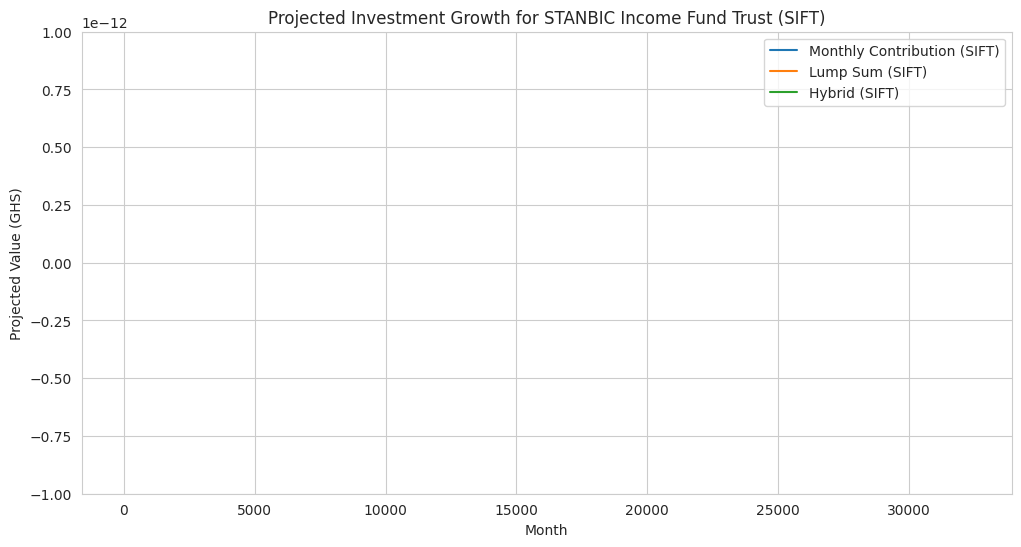

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gspread
from google.colab import auth
from google.auth import default # Import default credentials function
import pandas as pd # Ensure pandas is imported as it's used extensively

# Set a style for plots
sns.set_style("whitegrid")

# --- Google Sheet Integration Setup ---
# Authenticate with Google (interactive user authentication)
auth.authenticate_user()

# Get default credentials in the google-auth format
creds, project = default()

# Authenticate gspread with the obtained credentials
gc = gspread.authorize(creds)

# Open the Google Sheet and the specific worksheet
gsheet_url = 'https://docs.google.com/spreadsheets/d/1p5h13GBfHh3tpWQJ2w2RwUOA5p0g5OX1-EBNNT5yew0/edit?gid=545957380#gid=545957380'
spreadsheet = gc.open_by_url(gsheet_url)
worksheet = spreadsheet.worksheet('stanbic_sims')

# Helper function to safely read and convert float
def safe_read_float(cell_value, default_value):
    if cell_value is None or str(cell_value).strip() == '':
        return default_value
    try:
        return float(str(cell_value).replace(',', ''))
    except ValueError:
        print(f"Warning: Could not convert '{cell_value}' to float. Using default value.")
        return default_value

def safe_read_int(cell_value, default_value):
    if cell_value is None or str(cell_value).strip() == '':
        return default_value
    try:
        return int(float(str(cell_value).replace(',', '')))
    except ValueError:
        print(f"Warning: Could not convert '{cell_value}' to int. Using default value.")
        return default_value

# Read values from the specified cells
try:
    # User specified structure (updated based on new context):
    # B1: Amount in GHS (monthly contribution) - for monthly-only projection
    # B2: Amount in GHS (hybrid - monthly contribution) - Tier 2 of hybrid
    # B3: Amount in GHS (hybrid contribution / lump sum) - Tier 1 of hybrid
    # B4: Period (years)
    # B5: Amount in GHS (lump sum) - for lump-sum-only projection

    # Read cell B1: Monthly contribution for monthly-only scenario
    monthly_contribution_str = worksheet.acell('B1').value
    new_monthly_contribution = safe_read_float(monthly_contribution_str, 0)

    # Read cell B5: Lump sum for lump-sum-only scenario
    lump_sum_amount_str = worksheet.acell('B5').value # New cell for lump sum
    new_lump_sum_initial = safe_read_float(lump_sum_amount_str, 0)

    # Read cell B2: Hybrid monthly contribution (Tier 2)
    hybrid_monthly_contribution_str = worksheet.acell('B2').value
    new_hybrid_monthly = safe_read_float(hybrid_monthly_contribution_str, 0)

    # Read cell B3: Hybrid initial investment (Tier 1)
    hybrid_initial_investment_str = worksheet.acell('B3').value
    new_hybrid_initial = safe_read_float(hybrid_initial_investment_str, 0)

    # Read cell B4: Period (years)
    period_years_str = worksheet.acell('B4').value
    period_years = safe_read_int(period_years_str, 5) # Default 5 years for projection period
    projection_months = period_years * 12

    print(f"Successfully read inputs from Google Sheet (new schema):")
    print(f"  Monthly Contribution (B1): {new_monthly_contribution} GHS")
    print(f"  Lump Sum Initial (B5): {new_lump_sum_initial} GHS")
    print(f"  Hybrid Monthly Contribution (B2): {new_hybrid_monthly} GHS")
    print(f"  Hybrid Initial (B3): {new_hybrid_initial} GHS")
    print(f"  Projection Period (B4): {period_years} years ({projection_months} months)")

except Exception as e:
    print(f"An error occurred while reading from Google Sheet: {e}")
    print("Using default parameters for projection model due to read error. Investment amounts default to 0.")
    new_monthly_contribution = 0
    new_lump_sum_initial = 0
    new_hybrid_initial = 0
    new_hybrid_monthly = 0
    projection_months = 60 # 5 years default

# Define a function to write metrics to Google Sheet
def write_metrics_to_gsheet(metrics_dict, start_cell):
    output_data = []
    for k, v in metrics_dict.items():
        output_data.append([k, f"{v:.2f}"])
    # Update cells using named arguments to avoid DeprecationWarning
    worksheet.update(values=output_data, range_name=start_cell)

print("Google Sheet integration setup complete. Input parameters read.")
# --- End Google Sheet Integration Setup ---

def project_investment(
    fund_returns: pd.Series,
    initial_investment: float = 0.0,
    monthly_contribution: float = 0.0,
    projection_months: int = 12,
    scenario_name: str = "Projection",
    risk_adjustment_factor: float = 1.0 # 1.0 for no adjustment, <1.0 for conservative, >1.0 for aggressive
) -> pd.DataFrame:
    """
    Projects investment growth based on historical monthly returns.

    Args:
        fund_returns (pd.Series): Historical monthly returns of the fund.
        initial_investment (float): Initial lump-sum investment amount.
        monthly_contribution (float): Amount contributed each month.
        projection_months (int): Number of months to project.
        scenario_name (str): Name for the projection scenario.
        risk_adjustment_factor (float): Factor to adjust historical returns (e.g., 0.8 for 20% less return).

    Returns:
        pd.DataFrame: DataFrame containing monthly projected values and earnings.
    """
    if fund_returns.empty:
        print(f"Warning: Fund returns are empty for {scenario_name}. Returning empty DataFrame.")
        return pd.DataFrame()

    # Use the mean historical monthly return for projection
    # We'll use a constant rate for simplicity for now, but could be extended to Monte Carlo
    average_monthly_return = fund_returns.mean() * risk_adjustment_factor

    projected_values = []
    current_value = initial_investment

    # Simulate month by month
    for month in range(1, projection_months + 1):
        # Add monthly contribution before applying return (end of month contribution)
        current_value += monthly_contribution

        # Apply monthly return
        current_value *= (1 + average_monthly_return)
        projected_values.append(current_value)

    projected_df = pd.DataFrame({
        'Month': range(1, projection_months + 1),
        'Projected Value (GHS)': projected_values,
        'Scenario': scenario_name
    })

    # Calculate monthly earnings
    projected_df['Monthly Earnings (GHS)'] = projected_df['Projected Value (GHS)'].diff().fillna(projected_df['Projected Value (GHS)'] - initial_investment - monthly_contribution)

    # For the first month, earnings are just the growth on initial investment + contribution
    if initial_investment > 0 or monthly_contribution > 0:
        first_month_investment = initial_investment + monthly_contribution
        first_month_earnings = projected_df.loc[0, 'Projected Value (GHS)'] - first_month_investment
        projected_df.loc[0, 'Monthly Earnings (GHS)'] = first_month_earnings


    return projected_df

def calculate_metrics(projected_df: pd.DataFrame, initial_investment: float, total_contributions: float, projection_months: int):
    if projected_df.empty:
        return {"Message": "No data to calculate metrics."}

    final_value = projected_df['Projected Value (GHS)'].iloc[-1]
    total_invested = initial_investment + total_contributions
    total_earnings = final_value - total_invested
    projected_return_percentage = (total_earnings / total_invested) * 100 if total_invested > 0 else 0
    average_monthly_return_percentage = (projected_df['Projected Value (GHS)'].pct_change().mean() * 100) if projection_months > 1 else 0

    return {
        "Final Projected Value (GHS)": final_value,
        "Total Amount Invested (GHS)": total_invested,
        "Total Projected Earnings (GHS)": total_earnings,
        "Projected Total Return (%)": projected_return_percentage,
        "Average Monthly Projected Return (%)": average_monthly_return_percentage
    }

def plot_projections(projection_results: list[pd.DataFrame], title: str):
    if not projection_results:
        print("No data to plot.")
        return

    plt.figure(figsize=(12, 6))
    for df in projection_results:
        if not df.empty:
            plt.plot(df['Month'], df['Projected Value (GHS)'], label=df['Scenario'].iloc[0])

    plt.title(title)
    plt.xlabel('Month')
    plt.ylabel('Projected Value (GHS)')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_monthly_earnings(projection_results: list[pd.DataFrame], title: str):
    if not projection_results:
        print("No data to plot.")
        return

    plt.figure(figsize=(12, 6))
    # Corrected line: Use enumerate to get the index for positioning bars
    for i, df in enumerate(projection_results):
        if not df.empty:
            # Adjust x-position for each scenario to avoid overlapping bars
            bar_width = 0.2
            # Calculate a dynamic offset based on the number of scenarios to center the group of bars
            num_scenarios = len(projection_results)
            start_offset = - (num_scenarios - 1) * bar_width / 2
            x_positions = df['Month'] + start_offset + i * bar_width

            plt.bar(x_positions, df['Monthly Earnings (GHS)'], width=bar_width, label=df['Scenario'].iloc[0])

    plt.title(title)
    plt.xlabel('Month')
    plt.ylabel('Monthly Earnings (GHS)')
    plt.legend()
    plt.grid(True)
    plt.show()


# --- Updated Projections for STANBIC Income Fund Trust (SIFT) using Google Sheet inputs ---k
print("\n--- Running projections for STANBIC Income Fund Trust (SIFT) with Google Sheet inputs ---")

# Scenario 1: Monthly Contribution
projected_monthly_sift = project_investment(
    fund_returns=stanbic_sims_raw_statement_data['sift_monthly_returns'],
    initial_investment=0,
    monthly_contribution=new_monthly_contribution,
    projection_months=projection_months,
    scenario_name="Monthly Contribution (SIFT)"
)

print("\nMonthly Contribution Scenario (SIFT):")
print(projected_monthly_sift.head().to_markdown(index=False))
monthly_metrics_sift = calculate_metrics(projected_monthly_sift, 0, new_monthly_contribution * projection_months, projection_months)
for k, v in monthly_metrics_sift.items():
    print(f"{k}: {v:.2f}")

# Write SIFT Monthly Contribution metrics to GSheet
worksheet.update(range_name='F1', values=[['SIFT Monthly Contribution Metrics']])
write_metrics_to_gsheet(monthly_metrics_sift, 'F2')

# Scenario 2: Lump Sum Investment
projected_lump_sum_sift = project_investment(
    fund_returns=stanbic_sims_raw_statement_data['sift_monthly_returns'],
    initial_investment=new_lump_sum_initial,
    monthly_contribution=0,
    projection_months=projection_months,
    scenario_name="Lump Sum (SIFT)"
)
print("\nLump Sum Scenario (SIFT):")
print(projected_lump_sum_sift.head().to_markdown(index=False))
lump_sum_metrics_sift = calculate_metrics(projected_lump_sum_sift, new_lump_sum_initial, 0, projection_months)
for k, v in lump_sum_metrics_sift.items():
    print(f"{k}: {v:.2f}")

# Write SIFT Lump Sum metrics to GSheet
worksheet.update(range_name='F8', values=[['SIFT Lump Sum Metrics']])
write_metrics_to_gsheet(lump_sum_metrics_sift, 'F9')

# Scenario 3: Hybrid Investment
projected_hybrid_sift = project_investment(
    fund_returns=stanbic_sims_raw_statement_data['sift_monthly_returns'],
    initial_investment=new_hybrid_initial,
    monthly_contribution=new_hybrid_monthly,
    projection_months=projection_months,
    scenario_name="Hybrid (SIFT)"
)
print("\nHybrid Scenario (SIFT):")
print(projected_hybrid_sift.head().to_markdown(index=False))
hybrid_metrics_sift = calculate_metrics(projected_hybrid_sift, new_hybrid_initial, new_hybrid_monthly * projection_months, projection_months)
for k, v in hybrid_metrics_sift.items():
    print(f"{k}: {v:.2f}")

# Write SIFT Hybrid metrics to GSheet
worksheet.update(range_name='F15', values=[['SIFT Hybrid Metrics']])
write_metrics_to_gsheet(hybrid_metrics_sift, 'F16')

# Plotting all SIFT scenarios
plot_projections(
    [projected_monthly_sift, projected_lump_sum_sift, projected_hybrid_sift],
    "Projected Investment Growth for STANBIC Income Fund Trust (SIFT)"
)

# Plotting monthly earnings for all SIFT scenarios
plot_monthly_earnings(
    [projected_monthly_sift, projected_lump_sum_sift, projected_hybrid_sift],
    "Monthly Earnings for STANBIC Income Fund Trust (SIFT)"
)

# --- Projections for STANBIC INCOME FUND TRUST AMC using Google Sheet inputs ---
print("\n--- Running projections for STANBIC INCOME FUND TRUST AMC with Google Sheet inputs ---")

# Scenario 1: Monthly Contribution (AMC)
projected_monthly_amc = project_investment(
    fund_returns=stanbic_sims_raw_statement_data['amc_monthly_returns'],
    initial_investment=0,
    monthly_contribution=new_monthly_contribution,
    projection_months=projection_months,
    scenario_name="Monthly Contribution (AMC)"
)
print("\nMonthly Contribution Scenario (AMC):")
print(projected_monthly_amc.head().to_markdown(index=False))
monthly_metrics_amc = calculate_metrics(projected_monthly_amc, 0, new_monthly_contribution * projection_months, projection_months)
for k, v in monthly_metrics_amc.items():
    print(f"{k}: {v:.2f}")

# Write AMC Monthly Contribution metrics to GSheet
worksheet.update(range_name='I1', values=[['AMC Monthly Contribution Metrics']])
write_metrics_to_gsheet(monthly_metrics_amc, 'I2')

# Scenario 2: Lump Sum Investment (AMC)
projected_lump_sum_amc = project_investment(
    fund_returns=stanbic_sims_raw_statement_data['amc_monthly_returns'],
    initial_investment=new_lump_sum_initial,
    monthly_contribution=0,
    projection_months=projection_months,
    scenario_name="Lump Sum (AMC)"
)
print("\nLump Sum Scenario (AMC):")
print(projected_lump_sum_amc.head().to_markdown(index=False))
lump_sum_metrics_amc = calculate_metrics(projected_lump_sum_amc, new_lump_sum_initial, 0, projection_months)
for k, v in lump_sum_metrics_amc.items():
    print(f"{k}: {v:.2f}")

# Write AMC Lump Sum metrics to GSheet
worksheet.update(range_name='I8', values=[['AMC Lump Sum Metrics']])
write_metrics_to_gsheet(lump_sum_metrics_amc, 'I9')

# Scenario 3: Hybrid Investment (AMC)
projected_hybrid_amc = project_investment(
    fund_returns=stanbic_sims_raw_statement_data['amc_monthly_returns'],
    initial_investment=new_hybrid_initial,
    monthly_contribution=new_hybrid_monthly,
    projection_months=projection_months,
    scenario_name="Hybrid (AMC)"
)
print("\nHybrid Scenario (AMC):")
print(projected_hybrid_amc.head().to_markdown(index=False))
hybrid_metrics_amc = calculate_metrics(projected_hybrid_amc, new_hybrid_initial, new_hybrid_monthly * projection_months, projection_months)
for k, v in hybrid_metrics_amc.items():
    print(f"{k}: {v:.2f}")

# Write AMC Hybrid metrics to GSheet
worksheet.update(range_name='I15', values=[['AMC Hybrid Metrics']])
write_metrics_to_gsheet(hybrid_metrics_amc, 'I16')

# Plotting all AMC scenarios
plot_projections(
    [projected_monthly_amc, projected_lump_sum_amc, projected_hybrid_amc],
    "Projected Investment Growth for STANBIC INCOME FUND TRUST AMC"
)
plot_monthly_earnings(
    [projected_monthly_amc, projected_lump_sum_amc, projected_hybrid_amc],
    "Monthly Earnings for STANBIC INCOME FUND TRUST AMC"
)

print("\nInvestment projection model and scenarios with Google Sheet inputs completed.")


In [ ]:
# The user wants to generate visuals in Excel (Google Sheets).
# Directly generating Matplotlib/Seaborn plots as native charts within Google Sheets using gspread is not straightforward.
# gspread is primarily designed for reading and writing cell data.
# However, I can write the underlying data that these plots are based on (the projected values over time for each scenario)
# into your Google Sheet. You can then use this data to easily create charts directly within Google Sheets.

print("\n--- Preparing data for Google Sheets charts ---")

# Assuming 'worksheet' is already defined from cell dec6054d (stanbic_sims)

# Function to write a DataFrame to a specific range in the worksheet
def write_df_to_gsheet_range(dataframe, start_cell, worksheet):
    # Convert DataFrame to a list of lists for gspread, including headers
    data_to_write = [dataframe.columns.values.tolist()] + dataframe.values.tolist()
    worksheet.update(data_to_write, start_cell)
    print(f"Data successfully written to range '{start_cell}' in '{worksheet.title}'.")

# --- Prepare SIFT data for a single chart ---
# Merge all SIFT projection dataframes on 'Month'
sift_combined_chart_data = pd.DataFrame({'Month': range(1, projection_months + 1)})

# Use .fillna(0) for scenarios where there might be no projection data (like 0 initial investment)
sift_combined_chart_data = sift_combined_chart_data.merge(
    projected_monthly_sift[['Month', 'Projected Value (GHS)']].rename(columns={'Projected Value (GHS)': 'SIFT Monthly Value'}),
    on='Month', how='left'
).fillna(0)
sift_combined_chart_data = sift_combined_chart_data.merge(
    projected_lump_sum_sift[['Month', 'Projected Value (GHS)']].rename(columns={'Projected Value (GHS)': 'SIFT Lump Sum Value'}),
    on='Month', how='left'
).fillna(0)
sift_combined_chart_data = sift_combined_chart_data.merge(
    projected_hybrid_sift[['Month', 'Projected Value (GHS)']].rename(columns={'Projected Value (GHS)': 'SIFT Hybrid Value'}),
    on='Month', how='left'
).fillna(0)

# Write SIFT combined data to the worksheet starting from K1
write_df_to_gsheet_range(sift_combined_chart_data, 'K1', worksheet)


# --- Prepare AMC data for a single chart ---
# Merge all AMC projection dataframes on 'Month'
amc_combined_chart_data = pd.DataFrame({'Month': range(1, projection_months + 1)})

amc_combined_chart_data = amc_combined_chart_data.merge(
    projected_monthly_amc[['Month', 'Projected Value (GHS)']].rename(columns={'Projected Value (GHS)': 'AMC Monthly Value'}),
    on='Month', how='left'
).fillna(0)
amc_combined_chart_data = amc_combined_chart_data.merge(
    projected_lump_sum_amc[['Month', 'Projected Value (GHS)']].rename(columns={'Projected Value (GHS)': 'AMC Lump Sum Value'}),
    on='Month', how='left'
).fillna(0)
amc_combined_chart_data = amc_combined_chart_data.merge(
    projected_hybrid_amc[['Month', 'Projected Value (GHS)']].rename(columns={'Projected Value (GHS)': 'AMC Hybrid Value'}),
    on='Month', how='left'
).fillna(0)

# Write AMC combined data to the worksheet, starting after SIFT data
# Calculate the start row for AMC data (K1 + SIFT data rows + 2 blank rows)
amc_start_row = len(sift_combined_chart_data) + 5 # SIFT header (1) + SIFT data rows + 4 blank rows
write_df_to_gsheet_range(amc_combined_chart_data, f'K{amc_start_row}', worksheet)


print("\nData for charting has been written to the 'stanbic_sims' worksheet:")
print(f"- SIFT Projection Data (Monthly, Lump Sum, Hybrid) is available from K1 onwards.")
print(f"- AMC Projection Data (Monthly, Lump Sum, Hybrid) is available from K{amc_start_row} onwards.")
print("\nYou can now go to your Google Sheet to create charts. For example:\n1. For SIFT, select the range from K1 containing 'Month' and all 'SIFT' value columns.\n2. Go to Insert > Chart and choose a Line chart.\n3. Repeat for AMC data starting from K" + str(amc_start_row) + ".")
